In [1]:
!pip install numpy pandas scipy rasterio matplotlib tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 19.1 MB/s eta 0:00:00


In [2]:
# import the packages
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_origin
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from tqdm import tqdm


In [3]:
# Read the obtianed ground points
def read_ground_points(file_path):
    """
    Reads a space-separated ASCII file containing LiDAR points and extracts ground points.

    Parameters:
        file_path (str): Path to the ASCII .txt file.

    Returns:
        pd.DataFrame: Dataframe containing ground points (X, Y, Z).
    """
    # Read file with updated `sep='\s+'` to handle spaces
    df = pd.read_csv(file_path, sep='\s+', names=['X', 'Y', 'Z', 'Class'], engine='python')

    # Print preview of data
    print("\nFirst 5 rows of the loaded LiDAR file:")
    print(df.head())

    # Check unique classification values
    print("\nUnique classification values in dataset:", df['Class'].unique())

    # Filter only ground points (assuming ground class is 0)
    ground_points = df[df['Class'] == 0].reset_index(drop=True)

    # Print total ground points found
    print(f"\nTotal ground points extracted: {len(ground_points)}")

    return ground_points

In [4]:
# Function to read ASCII LiDAR file and extract vegetation points
def read_vegetation_points(file_path):
    """
    Reads a space-separated ASCII file containing LiDAR points
    and extracts vegetation points.

    Parameters:
        file_path (str): Path to the ASCII .txt file.

    Returns:
        pd.DataFrame: Dataframe containing vegetation points (X, Y, Z).
    """
    # Read file with space-separated values
    df = pd.read_csv(file_path, sep='\s+', names=['X', 'Y', 'Z', 'Class'], engine='python')

    # Print unique class values for debugging
    print("\nUnique classification values in dataset:", df['Class'].unique())

    # Filter vegetation points (assuming vegetation class is 1)
    vegetation_points = df[df['Class'] == 1].reset_index(drop=True)

    print(f"\nTotal vegetation points extracted: {len(vegetation_points)}")

    return vegetation_points

In [5]:
# Inverse Distance Weighting (IDW) Interpolation

def idw_interpolation(xyz, resolution=10):
    """
    Performs IDW interpolation on ground LiDAR points to generate a DTM.

    Parameters:
        xyz (pd.DataFrame): Dataframe with columns X, Y, Z.
        resolution (float): Grid resolution in meters.

    Returns:
        np.array: DTM raster array
        float: X min of the grid
        float: Y max of the grid
    """
    # Extract XYZ values
    x, y, z = xyz['X'].values, xyz['Y'].values, xyz['Z'].values

    # Define grid extents
    x_min, x_max = np.min(x), np.max(x)
    y_min, y_max = np.min(y), np.max(y)

    # Create grid points
    x_grid = np.arange(x_min, x_max, resolution)
    y_grid = np.arange(y_min, y_max, resolution)
    X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

    # Flatten grid for processing
    grid_points = np.vstack((X_grid.ravel(), Y_grid.ravel())).T

    # Build KDTree for fast neighbor search
    tree = cKDTree(np.c_[x, y])

    # Perform IDW interpolation
    Z_grid = np.zeros(grid_points.shape[0])

    for i in tqdm(range(grid_points.shape[0]), desc="Interpolating DTM"):
        distances, indices = tree.query(grid_points[i], k=5)  # 5 nearest neighbors
        if np.min(distances) == 0:  # Avoid division by zero
            Z_grid[i] = z[indices[0]]
        else:
            weights = 1.0 / distances  # IDW weights
            Z_grid[i] = np.sum(weights * z[indices]) / np.sum(weights)

    # Reshape to grid
    Z_grid = Z_grid.reshape(X_grid.shape)

    return Z_grid, x_min, y_max  # Returning y_max for raster transformation

In [6]:
# Save DTM as GeoTIFF

def save_dtm_raster(dtm_array, x_min, y_max, resolution, output_file):
    """
    Saves the DTM raster as a GeoTIFF.

    Parameters:
        dtm_array (np.array): DTM grid data.
        x_min (float): Minimum x-coordinate.
        y_max (float): Maximum y-coordinate.
        resolution (float): Grid resolution.
        output_file (str): Output filename for GeoTIFF.
    """
    height, width = dtm_array.shape
    transform = from_origin(x_min, y_max, resolution, resolution)

    with rasterio.open(
        output_file,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype=dtm_array.dtype,
        crs="EPSG:4326",  # Adjust CRS if necessary
        transform=transform,
    ) as dst:
        dst.write(dtm_array, 1)

    print(f"DTM saved as {output_file}")

In [7]:
# Visualize DTM
def plot_dtm(dtm_array):
    """
    Plots the generated DTM.

    Parameters:
        dtm_array (np.array): The DTM grid data.
    """
    plt.figure(figsize=(10, 6))
    plt.imshow(dtm_array, cmap='terrain', origin='upper')
    plt.colorbar(label="Elevation (m)")
    plt.title("Digital Terrain Model (DTM)")
    plt.xlabel("X Direction")
    plt.ylabel("Y Direction")
    plt.show()


In [8]:
# Mount and connect to the Google Drive
from google.colab import drive
drive.mount('/content/drive')
# "/content/drive/MyDrive/..."

Mounted at /content/drive


In [9]:
# Run an example

file_path = "/content/drive/MyDrive/AWD/24HN1_25/2_Filtered/Filtered_24HN1_25.LAZ.xyz"
output_dtm_file = "/content/drive/MyDrive/AWD/24HN1_25/3_DTM/24HN1_25.tif"  # Output GeoTIFF filename
resolution_meters = 10  # Set DTM resolution


In [10]:
# Read LiDAR data and extract ground points
ground_points = read_ground_points(file_path)



First 5 rows of the loaded LiDAR file:
           X           Y      Z  Class
0  93980.629  481250.065  6.484      0
1  93980.348  481250.204  6.373      0
2  93981.484  481250.087  6.256      0
3  93981.132  481250.261  6.293      0
4  93980.749  481250.452  6.378      0

Unique classification values in dataset: [0 1]

Total ground points extracted: 23660847


In [ ]:
print(len(ground_points))


0


In [ ]:
# Generate DTM using IDW interpolation
dtm, x_min, y_max = idw_interpolation(ground_points, resolution=resolution_meters)

# Save as raster
save_dtm_raster(dtm, x_min, y_max, resolution_meters, output_dtm_file)



Interpolating DTM: 100%|██████████| 13416/13416 [00:00<00:00, 18082.47it/s]

DTM saved as /content/drive/MyDrive/AWD/24HN1_25/3_DTM/24HN1_25.tif


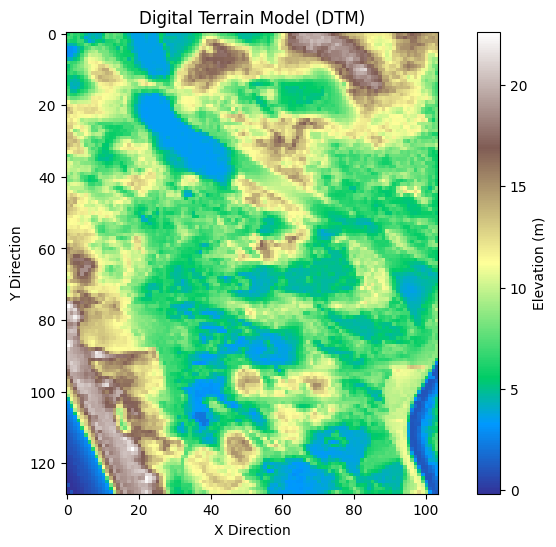

In [ ]:
# Visualize the DTM
plot_dtm(dtm)